In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import joblib

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [5]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [10]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.rename(columns={
    'v1': 'label',
    'v2': 'message'
}, inplace=True)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df['label'].value_counts()

,count
label,
0,4825
1,747


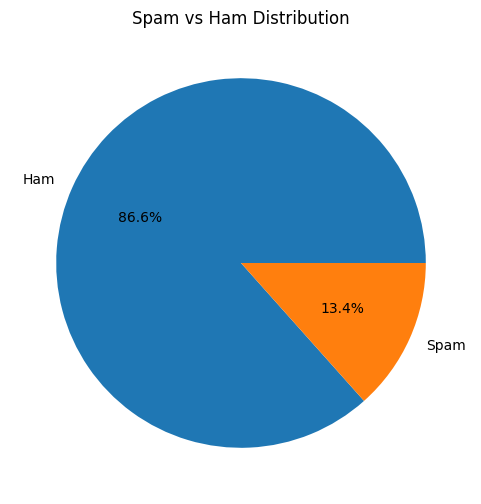

In [14]:
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

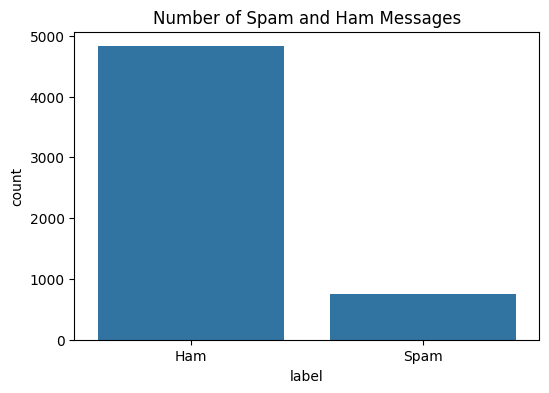

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.xticks([0,1], ['Ham','Spam'])

plt.title("Number of Spam and Ham Messages")

plt.show()

In [16]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


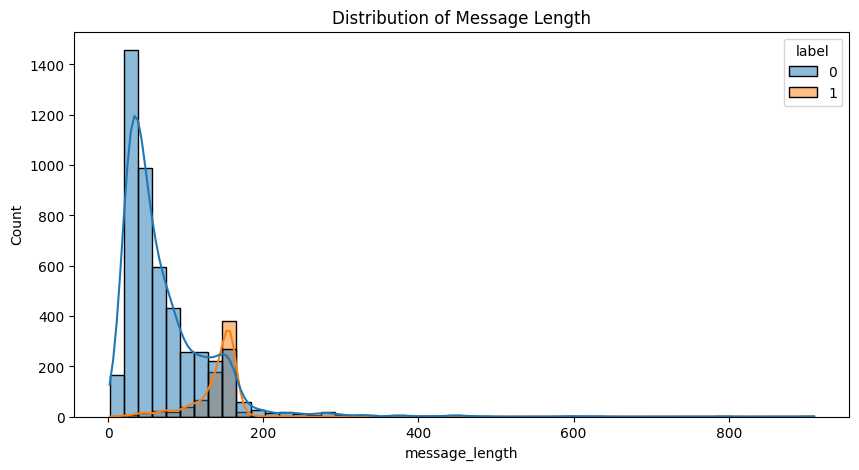

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50,
    kde=True
)

plt.title("Distribution of Message Length")

plt.show()

In [18]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 403


In [19]:
df = df.drop_duplicates()

print(df.shape)

(5169, 3)


In [20]:
df.isnull().sum()

,0
label,0
message,0
message_length,0


In [21]:
import string
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [22]:
ps = PorterStemmer()

In [23]:
def transform_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\d+', '', text)

    words = text.split()

    words = [
        ps.stem(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [24]:
df['processed_message'] = df['message'].apply(transform_text)

df.head()

,label,message,message_length,processed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goe usf live around though


In [25]:
df[['message', 'processed_message']].head(10)

,message,processed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea å£ ...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


In [26]:
df.isnull().sum()

,0
label,0
message,0
message_length,0
processed_message,0


In [27]:
df.to_csv("cleaned_spam.csv", index=False)

In [28]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['processed_message']).toarray()

y = df['label']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5169, 3000)
Target Shape: (5169,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4135, 3000)
Testing Data: (1034, 3000)


In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [31]:
y_pred_nb = nb_model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.9738878143133463


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[889   0]
 [ 27 118]]


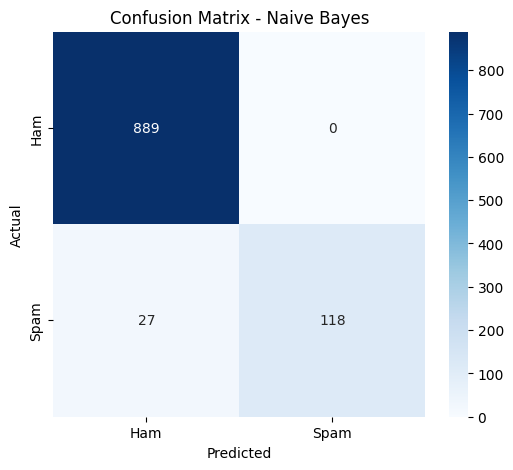

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.81      0.90       145

    accuracy                           0.97      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [36]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9526112185686654


In [37]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9796905222437138


In [38]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.973888
1,Logistic Regression,0.952611
2,Linear SVM,0.979691


In [39]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Linear SVM,0.979691
0,Naive Bayes,0.973888
1,Logistic Regression,0.952611


In [40]:
import joblib

joblib.dump(svm_model, "spam_classifier.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
import os

print(os.listdir())

['.config', 'spam.csv', 'spam_classifier.pkl', 'vectorizer.pkl', 'cleaned_spam.csv', 'sample_data']


In [42]:
from google.colab import files

files.download("spam_classifier.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
def predict_sms(message):

    processed = transform_text(message)

    vector = tfidf.transform([processed])

    prediction = svm_model.predict(vector)[0]

    if prediction == 1:
        print("🚨 Spam Message")
    else:
        print("✅ Ham Message")

In [44]:
predict_sms("Congratulations! You have won a FREE iPhone. Click here to claim.")

🚨 Spam Message


In [45]:
predict_sms("Hi Pradeep, are we meeting tomorrow at 10 AM?")

✅ Ham Message


In [46]:
predict_sms("Your account has been credited with Rs.1000")

✅ Ham Message


In [47]:
predict_sms("Win a free lottery now")

🚨 Spam Message
